# Seafloor age-grid anomalies as porphyry-Cu predictors through time


**Cluster K: Mineral exploration.**
*Based on:* Mather, Müller, Alfonso, Wright & Seton (2025), "Subducting seafloor anomalies promote porphyry copper formation", *International Geology Review* 67(19), 2170-2186.

**Reconstruct global porphyry-Cu deposit paleo-positions to multiple snapshot ages, sample the reconstructed seafloor age grid at each snapshot, detect age discontinuities with a Sobel edge filter, and show how the spatial association between porphyry-Cu localities and subducting age anomalies evolves through the Mesozoic-Cenozoic.**

## What this notebook produces

Three paleogeographic Mollweide maps, one per `SNAPSHOT_TIMES` age (defaults 0, 60, 120 Ma). Each map combines four layers:

- **Background**: reconstructed seafloor age grid at the snapshot age (via Plate Model Manager's `get_raster("AgeGrids", time=t)`). Bright = young crust at the ridge axes; dark = old crust nearing trenches.
- **Sobel-edge overlay**: top-percentile edge magnitudes from the age grid — these are the fracture-zone-like age discontinuities Mather et al. show are spatially associated with porphyry-Cu mineralisation when they subduct.
- **Reconstructed plate-boundary backbone** (gplately `PlotTopologies` at the snapshot age) in indianred.
- **Porphyry-Cu deposits** reconstructed to their *individual deposit ages* (Hoggard et al. 2020) and filtered to a ±15 Myr window around each snapshot. Sized by deposit count.

The headline observation is that through the Cenozoic-Mesozoic, porphyry-Cu deposits that were contemporary with high age-anomaly subducting crust are located close (within a few hundred km) of those age discontinuities — exactly the spatial correlation Mather et al. quantify with their full 9-notebook workflow.

**Audience:** postgrad.   **Difficulty:** ★★★.

## Learning objectives

- Reconstruct a deposit compilation to multiple paleo-snapshot ages using each row's individual host age (not the snapshot age).
- Sample a reconstructed paleo-age-grid at each snapshot via Plate Model Manager.
- Apply a Sobel edge filter to a paleo-age grid and render the top-percentile edges as a semi-transparent overlay over the age field itself.

## Prerequisites and runtime

- Plate model: Alfonso 2024 (mantle frame is fine here — this is a tectonic/mineral-systems analysis, not a paleoclimate one, so the paleomag-frame rule does not apply).
- Python: gplately, pygmt, pygplates, numpy, pandas, xarray, scipy.
- Bundled data: Whittaker 2015 LIP GPMLZ + hotspot GPMLZ + Hoggard 2020 base-metal Excel under `data/seafloor_anomalies_mather/`.
- Runtime: \~30 s (one PMM age-grid download per snapshot age, \~10 s each).


*Reference:* <https://github.com/brmather/SeafloorAnomalies>


## Configuration

In [1]:
# === USER CONFIGURATION =====================================================
from pathlib import Path
import os as _os
if Path("../data").exists() and not Path("data").exists():
    _os.chdir("..")

import numpy as np, pandas as pd
import gplately, pygmt, pygplates
import xarray as xr
from scipy import ndimage
from plate_model_manager import PlateModelManager
from IPython.display import display, HTML

MODEL_NAME       = "Alfonso2024"   # Mather et al. 2025 plate model
DATA_DIR         = Path("data/seafloor_anomalies_mather")
LIP_FILE         = DATA_DIR / "Whittaker_etal_2015_LIPs.gpmlz"
HOTSPOT_FILE     = DATA_DIR / "Hotspots_Compilation_Whittaker_etal.gpmlz"
DEPOSITS_XLS     = DATA_DIR / "base_metal_deposit_compilation.xls"

# Global snapshots — Mather et al. 2025 emphasise three Mesozoic-Cenozoic
# windows where porphyry-Cu formation peaks (Late-Cretaceous Laramide,
# present-day SW-Pacific arcs).
SNAPSHOT_TIMES   = (0.0, 28.0, 60.0, 100.0)   # Ma
DEP_WINDOW_MYR   = 15.0                        # contemporary deposits per snapshot

# Fracture-zone detection (Mather's grad + threshold + dilation pattern,
# replacing the simpler Sobel top-percentile).
FZ_GRAD_TOL      = 2.0     # min |gradient| (Ma/cell) to qualify as a fracture zone
FZ_DILATION_ITER = 1       # ndimage.binary_dilation iterations for visual coherence
AGE_VMAX         = 200.0   # colorbar maximum (Ma)

# Regional zoom boxes (Mather et al. 2025 canonical views)
# ============================================================================


## 1. Load Hoggard porphyry-Cu deposits + reconstruct each to its own host age

In [2]:
# Cell 2 — load Cu-por (porphyry-Cu) deposits + reconstruct
# Mather et al. (2025) restrict their porphyry-Cu analysis to the
# 'Cu-por' sheet of the Hoggard 2020 compilation. We follow the same
# deposit-rendering convention as Mather's 05-Relationship-to-mineral-
# deposits notebook: circles with size proportional to total commodity
# tonnage (Cu + Pb + Zn + Ni in Mt) and colour mapped from deposit age
# in Ma via a sequential cmocean palette.
pmm   = PlateModelManager()
model = pmm.get_model(MODEL_NAME, data_dir="./gplately_data")
recon = gplately.PlateReconstruction(
    rotation_model=model.get_rotation_model(),
    topology_features=model.get_topologies(),
    static_polygons=model.get_static_polygons())

deps = pd.read_excel(DEPOSITS_XLS, sheet_name="Cu-por", na_values="ND")
deps = deps[deps["Age (Ga)"].notna()].copy()
deps["age_Ma"] = deps["Age (Ga)"].astype(float) * 1000.0
deps["lon"]    = deps["Lon"].astype(float)
deps["lat"]    = deps["Lat"].astype(float)

# Total commodity tonnage per deposit (Mt) — Mather sums Cu+Pb+Zn+Ni
COMMODITIES = ["Cu (Mt)", "Pb (Mt)", "Zn (Mt)", "Ni (Mt)"]
deps["tonnage_Mt"] = 0.0
for col in COMMODITIES:
    if col in deps.columns:
        deps["tonnage_Mt"] = deps["tonnage_Mt"] + deps[col].fillna(0.0).astype(float)
print(f"  tonnage range: {deps['tonnage_Mt'].min():.1f} – {deps['tonnage_Mt'].max():.1f} Mt")

# Drop any rows still missing essentials
deps = deps.dropna(subset=["lon", "lat", "age_Ma"]).reset_index(drop=True)
print(f"  {len(deps)} Cu-por deposits loaded with complete lon/lat/age")

# Partitioner-drop guard: build a single Points object, read back the
# plate IDs, drop those with plate_id <= 0 (otherwise they reconstruct
# to ocean locations).
pts = gplately.Points(recon, deps["lon"].values, deps["lat"].values)
plate_ids = np.atleast_1d(pts.plate_id).astype(int)
valid = plate_ids > 0
if (~valid).any():
    print(f"  dropping {int((~valid).sum())} deposits whose modern coords "
          f"did not partition to any continental polygon (would reconstruct "
          f"to ocean locations)")
    deps = deps.loc[valid].reset_index(drop=True)
    pts  = gplately.Points(recon, deps["lon"].values, deps["lat"].values)
print(f"  {len(deps)} Cu-por deposits with valid continental plate IDs")
print(f"  age range: {deps['age_Ma'].min():.0f} – {deps['age_Ma'].max():.0f} Ma")

# Pre-compute pyGMT circle-size column in centimetres.
# Mather's matplotlib formula: s = 20 + tonnage*8 where s is the marker
# AREA in points². Diameter scales as sqrt(area), giving large deposits
# ~5× the visible diameter of small ones. We mirror that in cm with a
# sqrt-of-tonnage curve so big porphyry-Cu giants stand out clearly.
# Factor-of-3 size spread: 0.20 cm (zero tonnage) to 0.60 cm (max
# tonnage). Sqrt curve keeps small-deposit differences visible without
# giant deposits dwarfing everything else. Empirically chosen to land
# between the original factor-of-6 and the recent factor-of-2 versions.
t_max = max(float(deps["tonnage_Mt"].max()), 1.0)
deps["size_cm"] = 0.20 + 0.40 * np.sqrt(
    deps["tonnage_Mt"].fillna(0.0).clip(lower=0) / t_max)
print(f"  deposit-circle size_cm range: "
      f"{deps['size_cm'].min():.2f} – {deps['size_cm'].max():.2f} cm")

# LIPs (Whittaker 2015) as a reconstructable FeatureCollection
LIPs = pygplates.FeatureCollection(str(LIP_FILE))
print(f"\n  loaded {len(LIPs)} LIP features (Whittaker 2015)")


  tonnage range: 0.0 – 128.5 Mt
  594 Cu-por deposits loaded with complete lon/lat/age
  594 Cu-por deposits with valid continental plate IDs
  age range: 1 – 3234 Ma
  deposit-circle size_cm range: 0.20 – 0.60 cm



  loaded 80 LIP features (Whittaker 2015)


## 2. Render: paleo-age grid + Sobel edges + paleo-position deposits, per snapshot age

makecpt [WARNING]: Without inc in -T option, -Z has no effect (ignored)


grdimage [WARNING]: Longitude range too small; geographic boundary condition changed to natural.


makecpt [WARNING]: cmocean/deep is a discrete CPT. You can stretch it (-T<min>/<max>) but not interpolate it (-T<min>/<max>/<inc>).


makecpt [WARNING]: Selecting the given range and ignoring the increment setting.


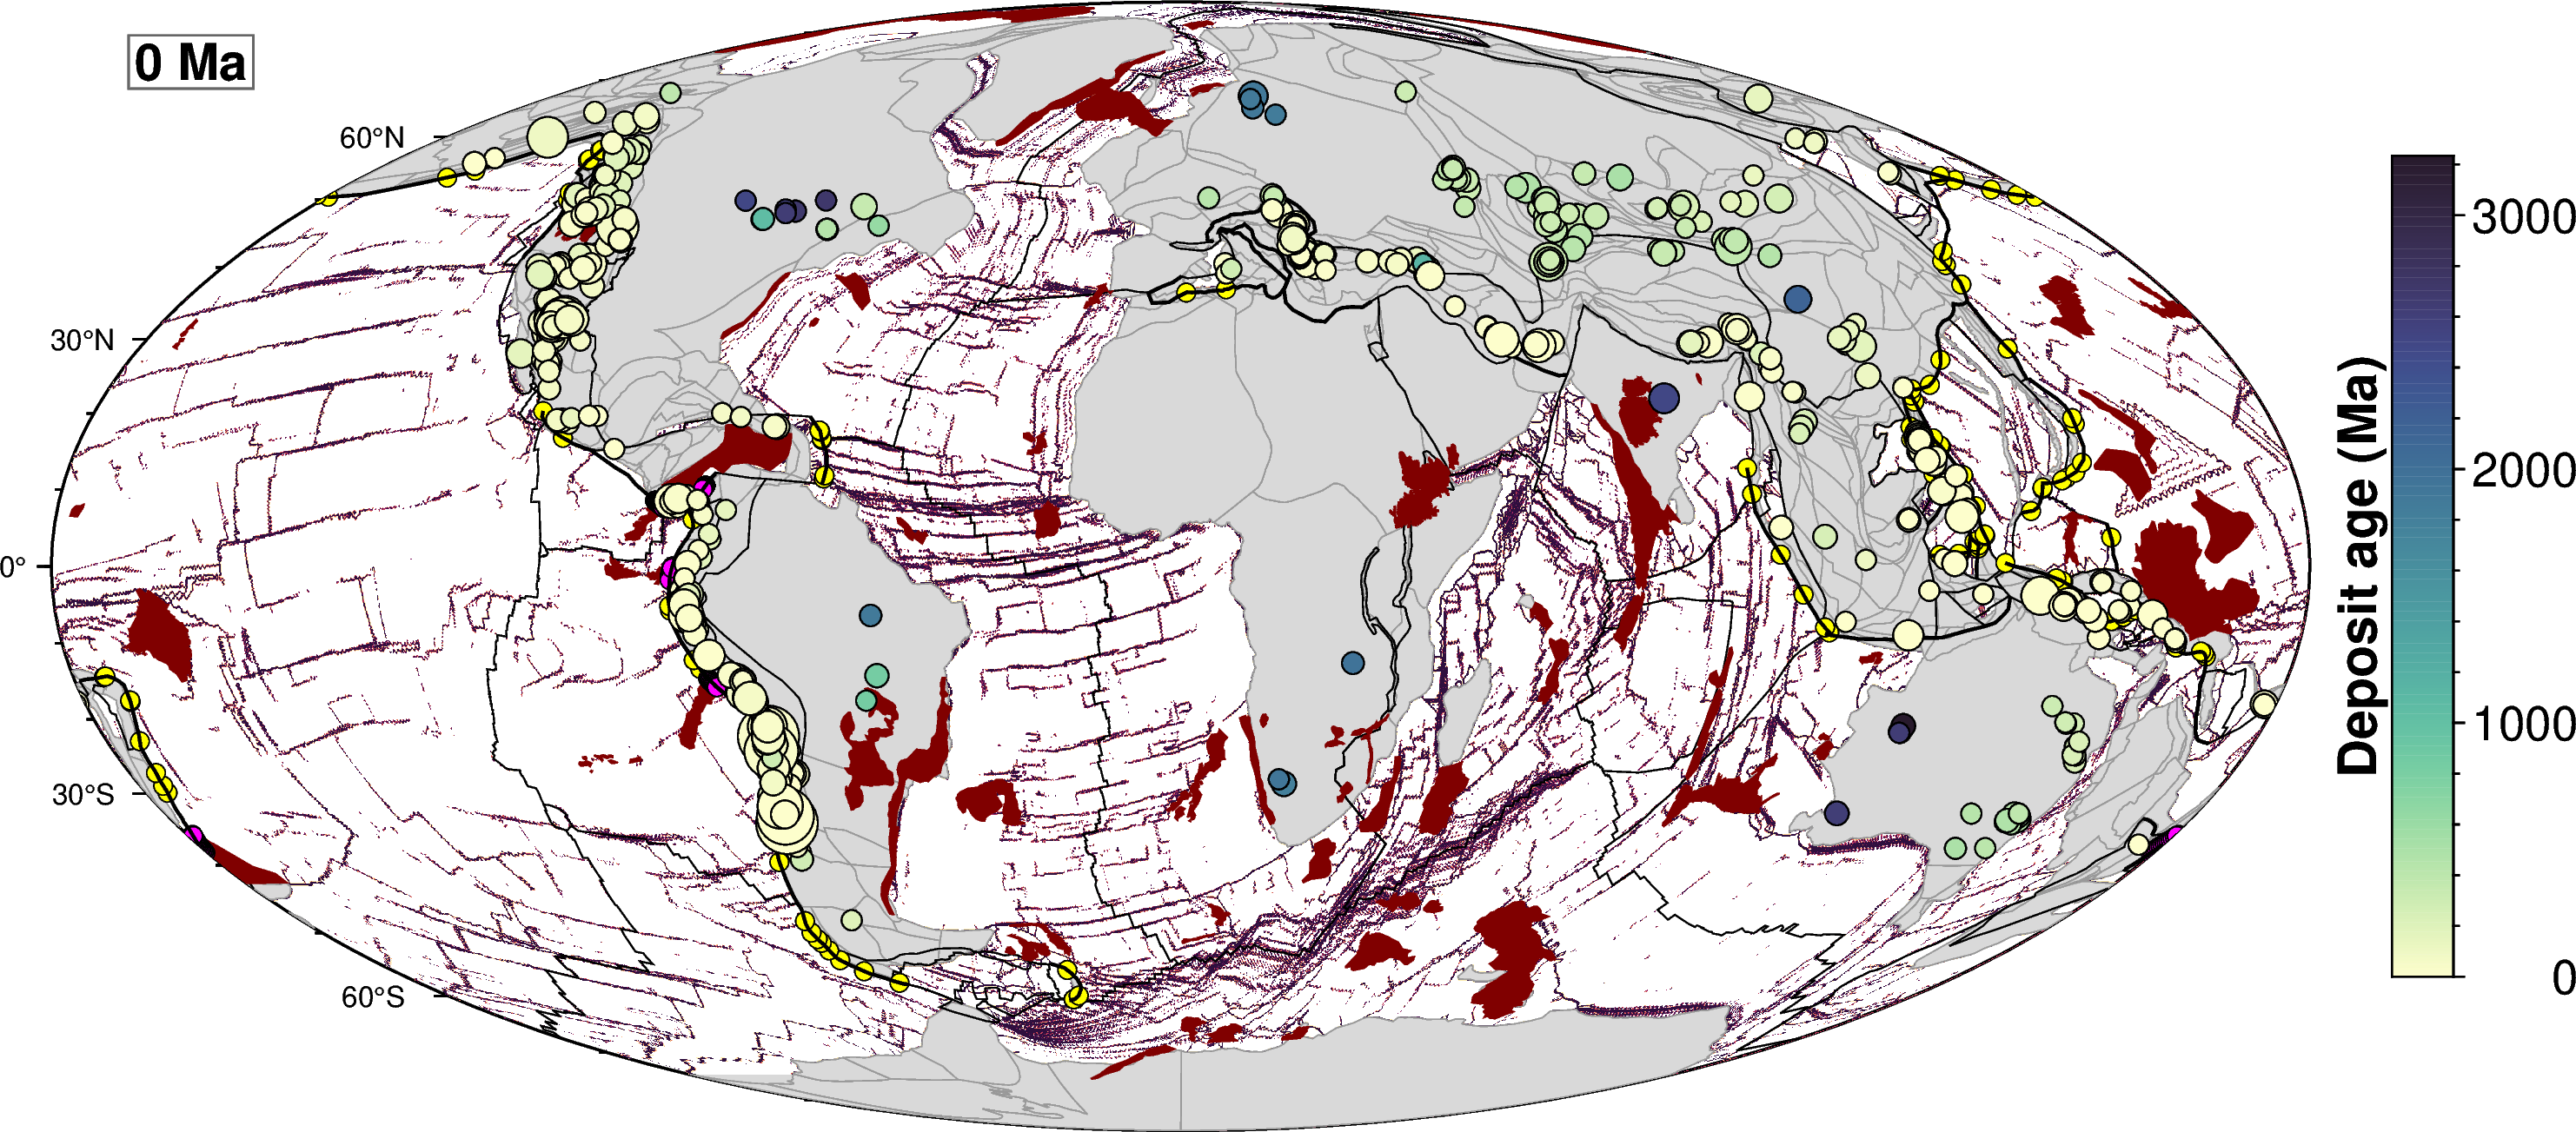

makecpt [WARNING]: Without inc in -T option, -Z has no effect (ignored)


grdimage [WARNING]: Longitude range too small; geographic boundary condition changed to natural.


makecpt [WARNING]: cmocean/deep is a discrete CPT. You can stretch it (-T<min>/<max>) but not interpolate it (-T<min>/<max>/<inc>).


makecpt [WARNING]: Selecting the given range and ignoring the increment setting.


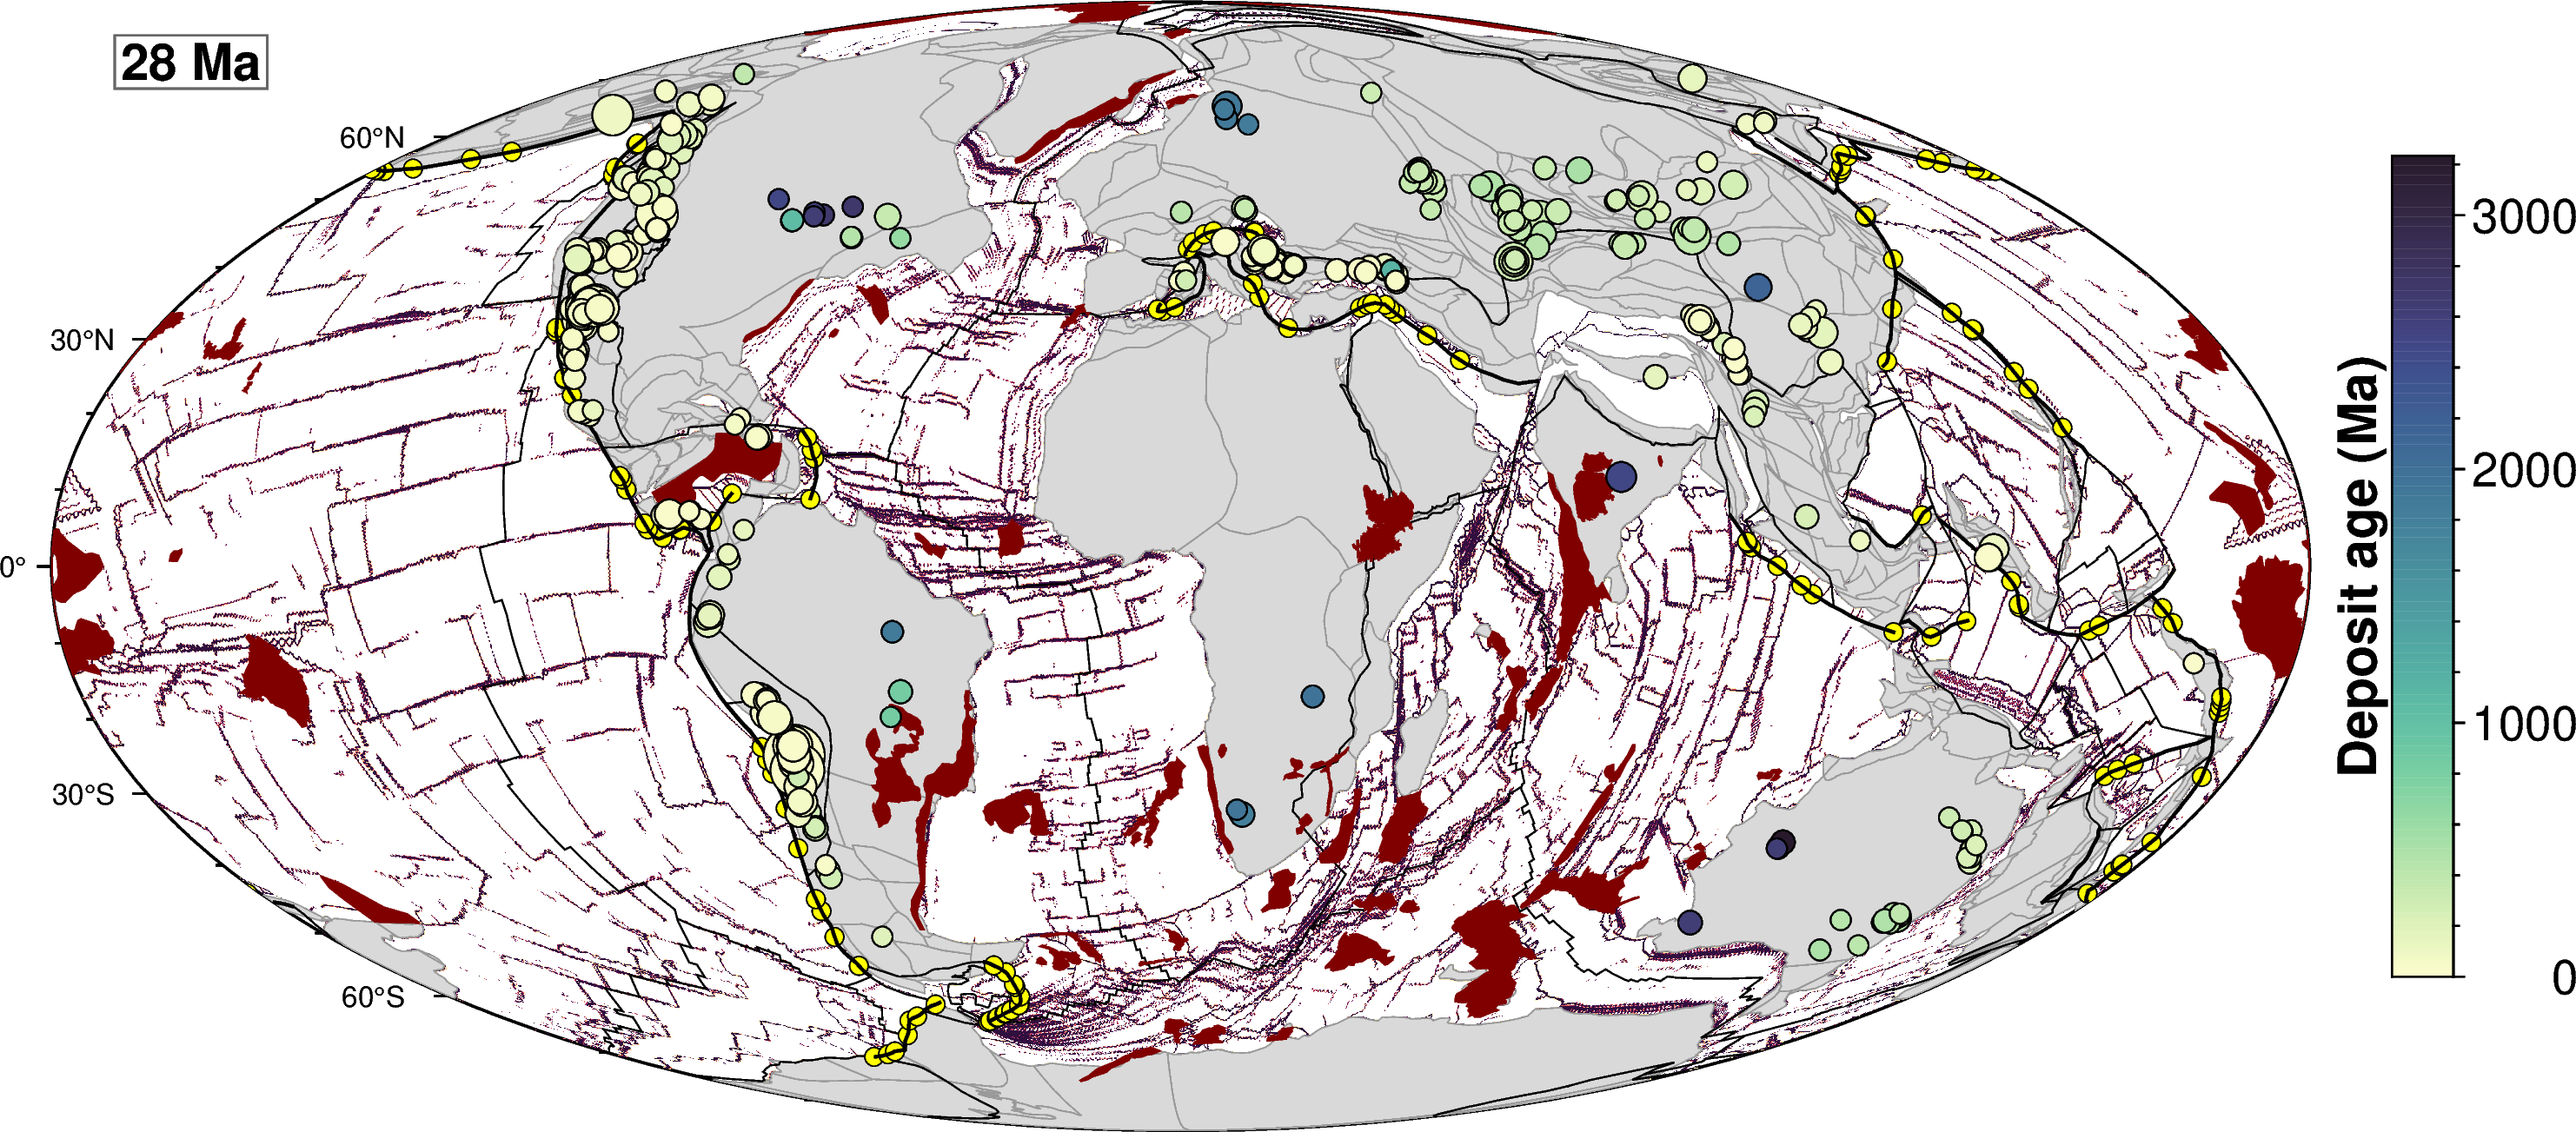

makecpt [WARNING]: Without inc in -T option, -Z has no effect (ignored)


grdimage [WARNING]: Longitude range too small; geographic boundary condition changed to natural.


makecpt [WARNING]: cmocean/deep is a discrete CPT. You can stretch it (-T<min>/<max>) but not interpolate it (-T<min>/<max>/<inc>).


makecpt [WARNING]: Selecting the given range and ignoring the increment setting.


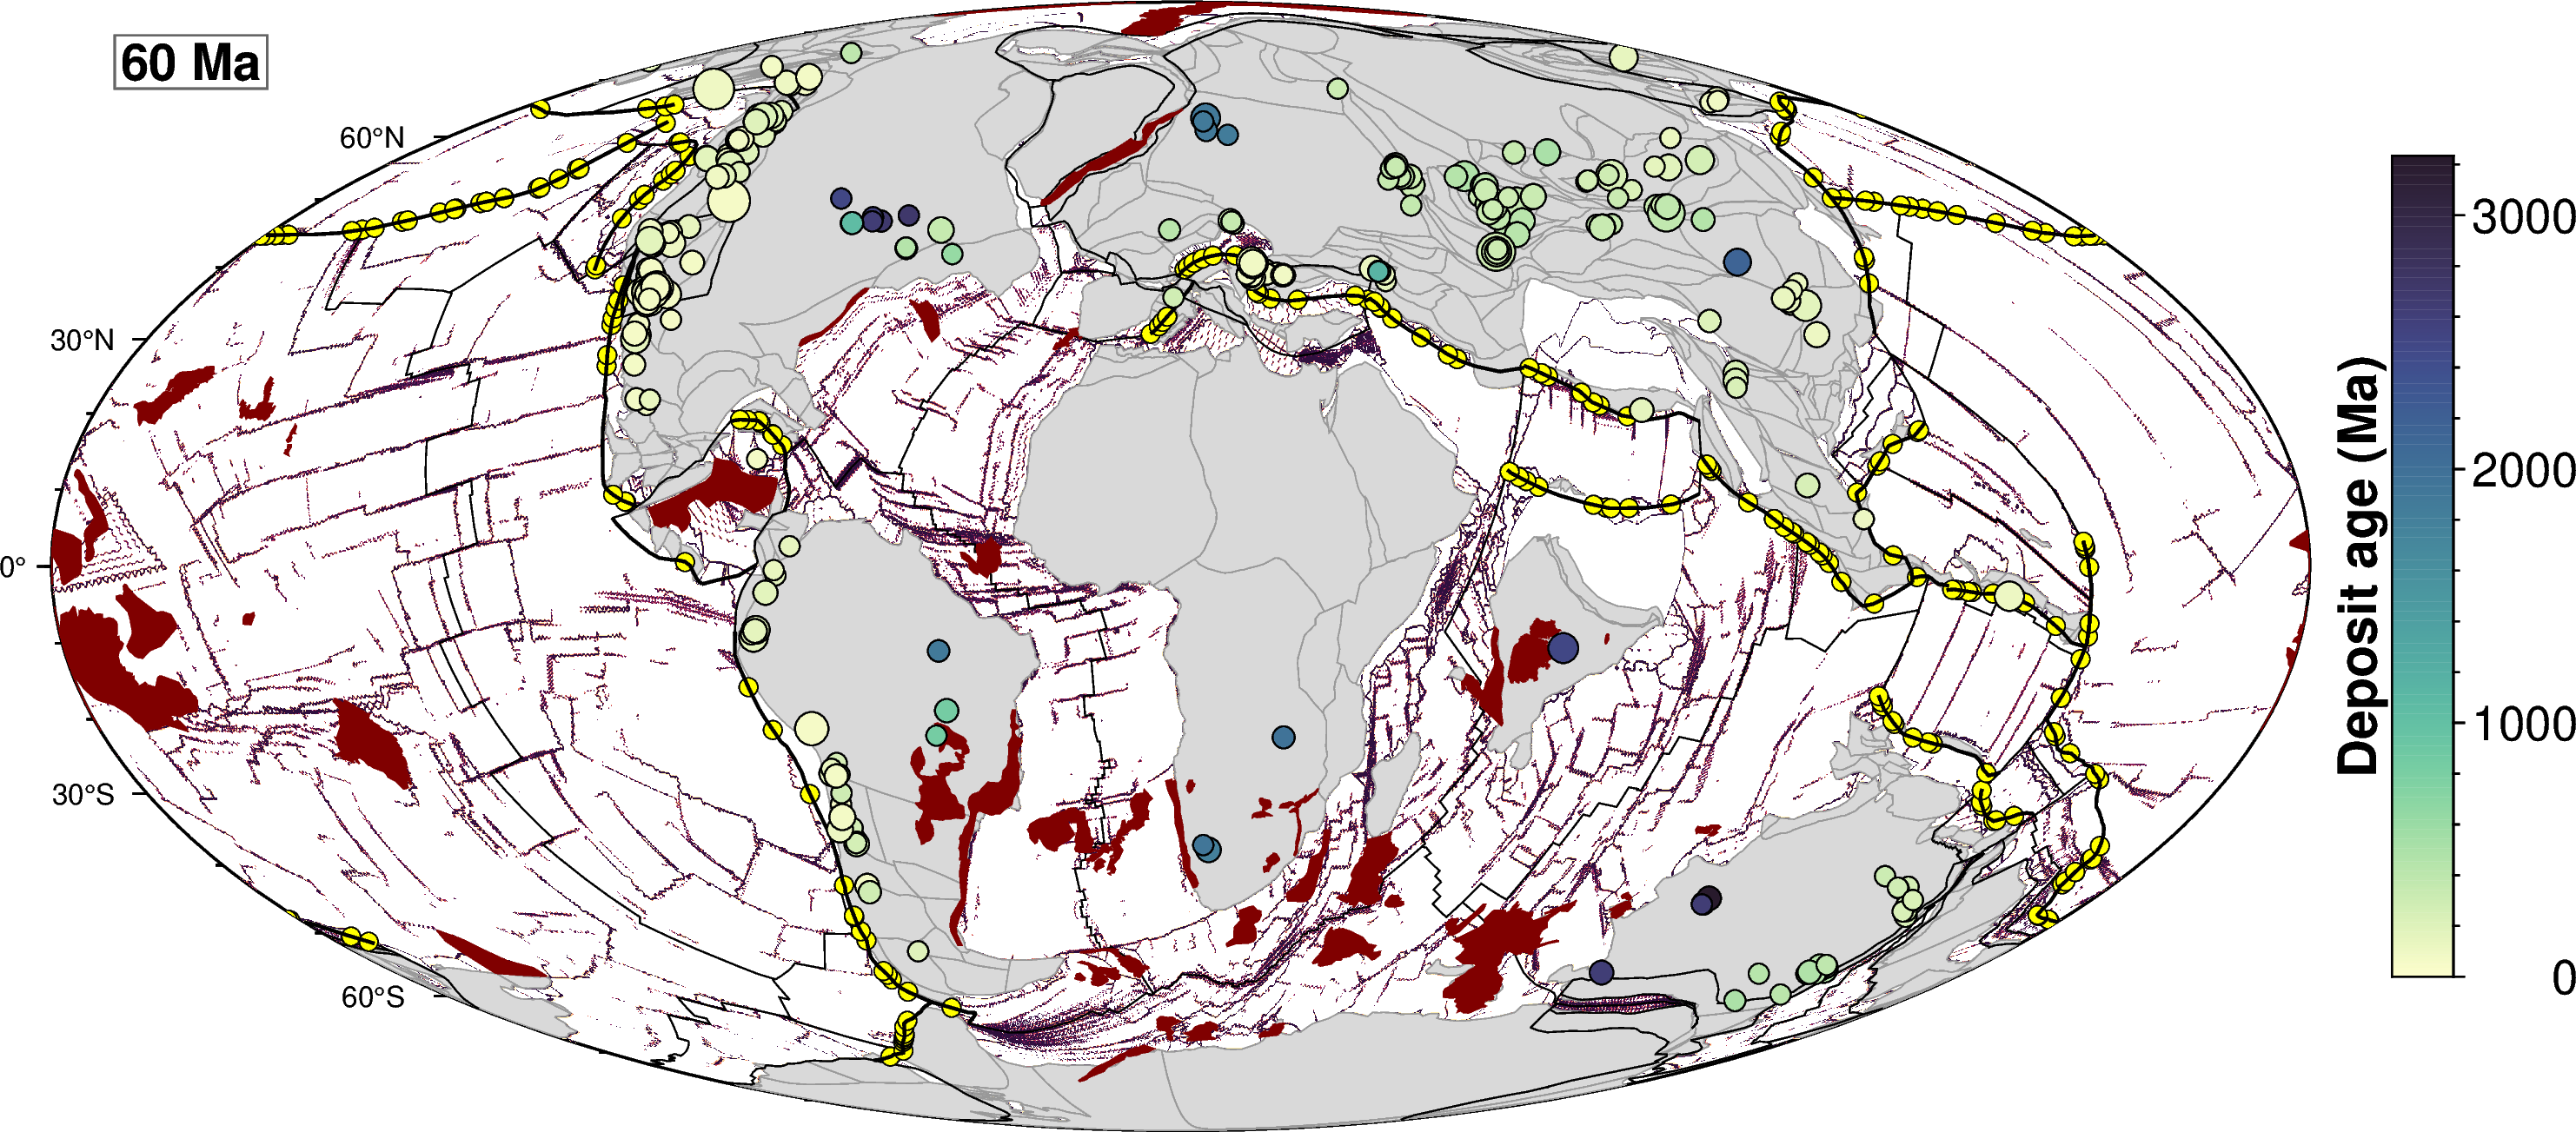

makecpt [WARNING]: Without inc in -T option, -Z has no effect (ignored)


grdimage [WARNING]: Longitude range too small; geographic boundary condition changed to natural.


makecpt [WARNING]: cmocean/deep is a discrete CPT. You can stretch it (-T<min>/<max>) but not interpolate it (-T<min>/<max>/<inc>).


makecpt [WARNING]: Selecting the given range and ignoring the increment setting.


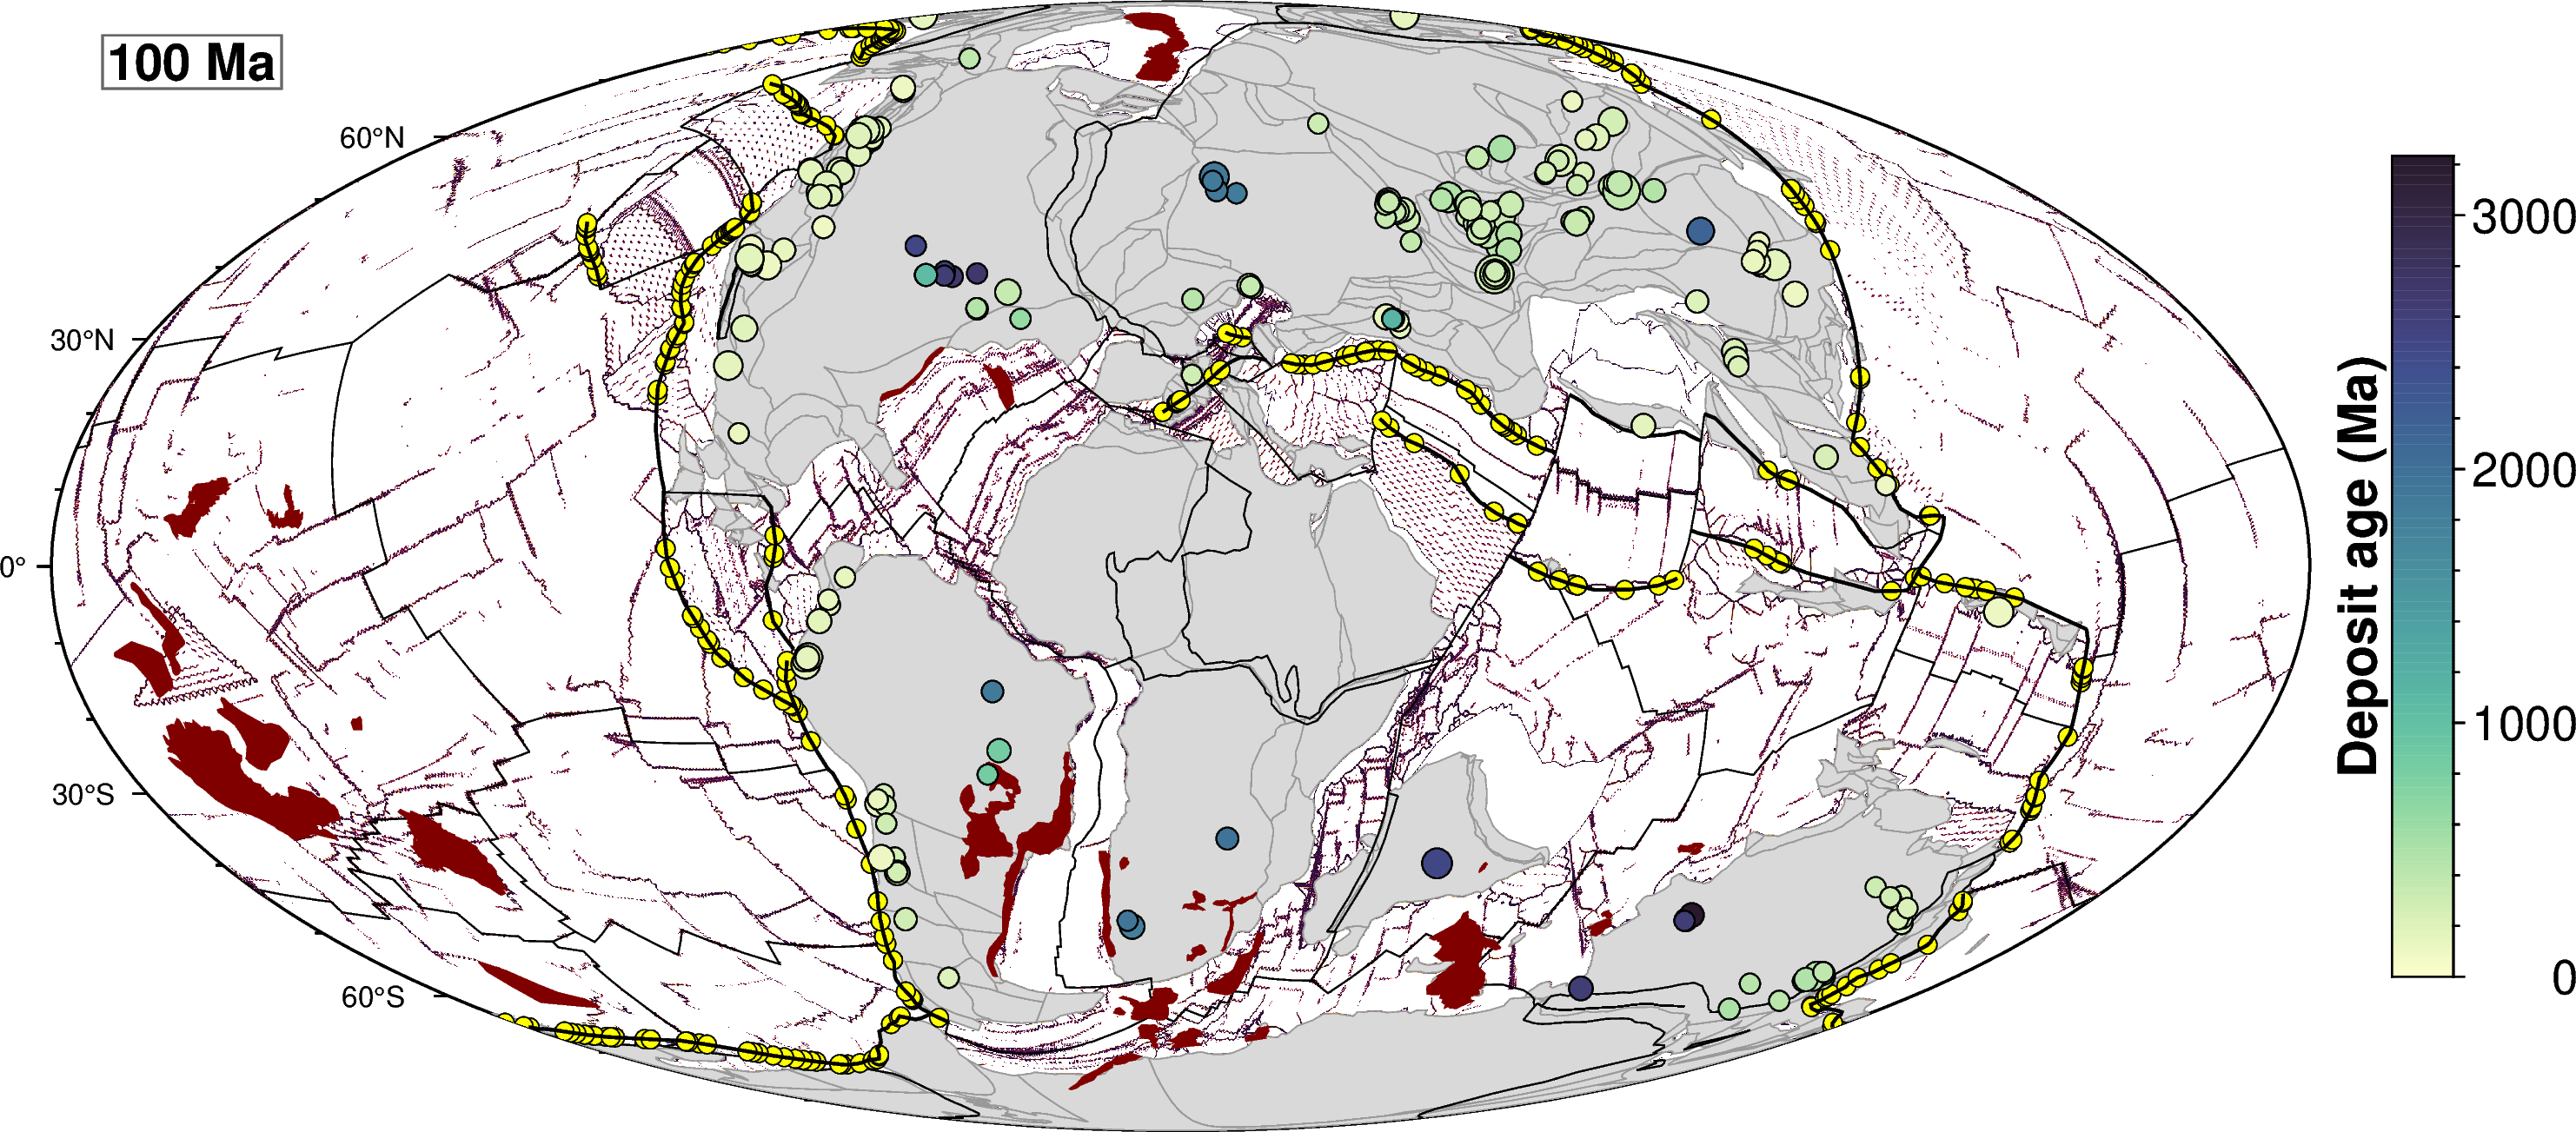

In [3]:
# Cell 3 — render: per-snapshot map in Mather's plot_timeseries style
# Visual conventions mirror 06-Plot-Timeseries cell 8 of Mather et al. 2025:
#   - BACKGROUND: fracture-zone gradient magnitude (cmocean/matter)
#   - continents in gray85, plate boundaries + trenches in BLACK
#   - reconstructed LIPs filled in MAROON
#   - fracture-zone × trench intersections in YELLOW
#   - LIP × trench intersections in MAGENTA
#   - Cu-por deposits (orange triangles) — only those with host_age >= t
#   - time stamp 'XXXX Ma' top-left
def fz_gradient_raster(age_grid, tol_grad=FZ_GRAD_TOL,
                       iter_dilation=FZ_DILATION_ITER):
    """Mather's grad(): fill NaNs, compute |gradient|, threshold + dilate,
    return a raster of the GRADIENT-MAGNITUDE values where the threshold
    is exceeded (NaN elsewhere)."""
    arr = age_grid.values.astype(float)
    filled = np.where(np.isnan(arr), 0.0, arr)
    gx, gy = np.gradient(filled)
    mag = np.hypot(gx, gy)
    mask = mag > tol_grad
    if iter_dilation > 0:
        mask = ndimage.binary_dilation(mask, iterations=iter_dilation)
    out = np.where(mask, mag, np.nan)
    out[np.isnan(arr)] = np.nan
    return xr.DataArray(
        out, dims=age_grid.dims,
        coords={d: age_grid.coords[d] for d in age_grid.dims},
        name="fz_gradient")

from scipy.spatial import cKDTree

def trench_intersect_lonlats(subduction_data, anomaly_lons, anomaly_lats,
                              dtol_km=50.0):
    """Return (lon, lat) of trench segments within dtol_km of any anomaly
    point (Mather's reconstruct_LIP_subduction pattern)."""
    if len(anomaly_lons) == 0 or len(subduction_data) == 0:
        return np.array([]), np.array([])
    tlon = subduction_data[:, 0]; tlat = subduction_data[:, 1]
    def llxyz(lon, lat):
        lon_r = np.deg2rad(lon); lat_r = np.deg2rad(lat)
        return np.c_[np.cos(lat_r)*np.cos(lon_r),
                     np.cos(lat_r)*np.sin(lon_r),
                     np.sin(lat_r)]
    txyz = llxyz(tlon, tlat); axyz = llxyz(anomaly_lons, anomaly_lats)
    tree = cKDTree(txyz)
    d, _ = tree.query(axyz)
    d *= 6371.0
    sel = d <= dtol_km
    if not np.any(sel):
        return np.array([]), np.array([])
    _, idx = tree.query(axyz[sel])
    return tlon[idx], tlat[idx]

def render_snapshot(t, region="d", projection="W0/22c", banner_label=None):
    if banner_label:
        display(HTML(f'<div style="margin-top:1cm; padding:0.4em 0.8em; '
                      f'background:#fde8e8; border-left:5px solid #b00020; '
                      f'font-size:14pt; font-weight:bold; '
                      f'font-family:Helvetica;">{banner_label}</div>'))

    # Age grid at this snapshot age (reconstructed, via PMM)
    age_grid_path = model.get_raster("AgeGrids", time=int(t))
    ds = xr.open_dataset(age_grid_path)
    age_var = next((v for v in ds.data_vars
                    if any(k in v.lower() for k in ("age", "seafloor", "z"))),
                   list(ds.data_vars)[0])
    age = ds[age_var]
    if "y" in age.dims and "lat" not in age.dims:
        age = age.rename({"y": "lat", "x": "lon"})
    if "lon" not in age.dims and "x" in age.dims:
        age = age.rename({"x": "lon"})

    fz = fz_gradient_raster(age)

    sub_data = recon.tessellate_subduction_zones(
        float(t), tessellation_threshold_radians=np.deg2rad(0.2))

    gplot = gplately.PlotTopologies(
        plate_reconstruction=recon,
        coastlines=model.get_coastlines(),
        continents=model.get_continental_polygons(),
        COBs=model.get_COBs(), time=float(t),
        plot_engine=gplately.PygmtPlotEngine(),
        )

    # Reconstructed LIPs at snapshot age + their point cloud
    LIPs_at_t = []
    try:
        pygplates.reconstruct(LIPs, recon.rotation_model, LIPs_at_t, float(t))
    except Exception:
        pass
    LIP_lon_pts, LIP_lat_pts = [], []
    for f in LIPs_at_t:
        geom = f.get_reconstructed_geometry()
        if geom is None: continue
        try:
            for la, lo in geom.to_lat_lon_list():
                LIP_lat_pts.append(la); LIP_lon_pts.append(lo)
        except Exception:
            continue

    # Trench × FZ intersections
    fz_idx = np.where(np.isfinite(fz.values))
    fz_anom_lon = fz["lon"].values[fz_idx[1]]
    fz_anom_lat = fz["lat"].values[fz_idx[0]]
    if len(fz_anom_lon) > 5000:
        keep = np.linspace(0, len(fz_anom_lon)-1, 5000).astype(int)
        fz_anom_lon = fz_anom_lon[keep]; fz_anom_lat = fz_anom_lat[keep]
    fz_x_lon, fz_x_lat = trench_intersect_lonlats(sub_data,
                                                   fz_anom_lon, fz_anom_lat)
    lip_x_lon, lip_x_lat = trench_intersect_lonlats(sub_data,
                                                     np.asarray(LIP_lon_pts),
                                                     np.asarray(LIP_lat_pts))

    fig = pygmt.Figure()
    fig.basemap(region=region, projection=projection, frame=["af"])

    # === BACKGROUND: fracture-zone gradient (cmocean/matter) ===
    pygmt.makecpt(cmap="cmocean/matter", series=[0, 2.0],
                  background="o", continuous=True)
    if np.any(np.isfinite(fz.values)):
        # Fracture-zone gradient field — qualitative overlay; bright
        # purple = sharp age discontinuity (= subducting fracture zone).
        # No colorbar drawn: the cmocean/matter ramp is a visual cue,
        # not a calibrated scale, so a colorbar would just clutter the
        # figure with Ma/cell numbers that depend on the grid spacing.
        fig.grdimage(grid=fz, cmap=True, nan_transparent=True)

    # === Continents (gray85) ===
    gplot.plot_continents(fig, fill="gray85", pen="0.3p,gray60")

    # === Plate boundaries (black) ===
    try:
        gplot.plot_all_topological_sections(fig, pen="0.4p,black")
    except Exception:
        pass

    # === LIPs (maroon) ===
    for f in LIPs_at_t:
        geom = f.get_reconstructed_geometry()
        if geom is None: continue
        try:
            lats, lons = zip(*geom.to_lat_lon_list())
            fig.plot(x=list(lons), y=list(lats),
                     fill="#800000", pen="0.4p,#800000", close=True)
        except Exception:
            continue

    # === Trench × FZ (yellow) ===
    if len(fz_x_lon):
        fig.plot(x=fz_x_lon, y=fz_x_lat, style="c0.18c",
                 fill="#FFFF00", pen="0.3p,black")

    # === Trench × LIP (magenta) ===
    if len(lip_x_lon):
        fig.plot(x=lip_x_lon, y=lip_x_lat, style="c0.18c",
                 fill="#FF00FF", pen="0.3p,black")

    # === Trenches in black ===
    try:
        gplot.plot_trenches(fig, pen="0.9p,black")
    except Exception:
        pass

    # === Cu-por deposits ===
    # Mather's deposit-scatter convention (05-Relationship-to-mineral-
    # deposits.ipynb): CIRCLES, size proportional to commodity tonnage
    # (Cu+Pb+Zn+Ni Mt), colour mapped from host age via a sequential
    # cmocean palette. We use cmocean/deep (light = young, dark = old).
    rlon, rlat = pts.reconstruct(float(t), return_array=True)
    n_back = min(len(rlon), len(deps))
    mask_existing = deps["age_Ma"].values[:n_back] >= t
    if mask_existing.any():
        # Switch the active CPT to the AGE palette (cmocean/deep)
        pygmt.makecpt(cmap="cmocean/deep",
                      series=[0, max(float(deps["age_Ma"].max()), 200.0), 10],
                      background="o", continuous=True)
        fig.plot(x=rlon[:n_back][mask_existing],
                 y=rlat[:n_back][mask_existing],
                 size=deps["size_cm"].values[:n_back][mask_existing],
                 style="cc",
                 fill=deps["age_Ma"].values[:n_back][mask_existing],
                 cmap=True, pen="0.4p,black")
        # Second colorbar (right of the figure) for deposit age — bumped
        # HARD (18/20 pt) for paper-figure legibility at journal print size;
        # bar made thicker (0.6c) and longer (8c) to match the larger type.
        pygmt.config(FONT_ANNOT_PRIMARY="18p,Helvetica,black",
                     FONT_LABEL="20p,Helvetica-Bold,black")
        fig.colorbar(frame="af+lDeposit age (Ma)",
                     position="JMR+w8c/0.6c+ml+o0.8c/0c")

    # === Time stamp ===
    fig.text(text=f"{int(t):4d} Ma",
             position="TL", offset="0.4c/-0.4c", justify="TL",
             font="14p,Helvetica-Bold,black",
             fill="white", pen="0.6p,gray40")
    fig.show(width=1100)
    display(HTML('<div style="height:1cm"></div>'))

# Four global snapshots
for t in SNAPSHOT_TIMES:
    render_snapshot(t, region="d", projection="W0/22c",
                    banner_label=f"GLOBAL — {t:.0f} Ma — {MODEL_NAME}")


## What the figure shows

Paleogeographic maps, one per snapshot age in `SNAPSHOT_TIMES`, all rendered in the visual idiom of Mather et al. (2025, https://github.com/brmather/SeafloorAnomalies; their `06-Plot-Timeseries.ipynb`). Read each as:

- **Background field — `cmocean/matter` palette.** This is **not** the seafloor age grid itself but the *magnitude of its spatial gradient*, computed via `np.gradient` and thresholded at `FZ_GRAD_TOL`, then dilated to make the features visible at world-projection scale. Bright purple-pink corresponds to a sharp seafloor-age discontinuity — i.e. a subducting fracture zone — and dark red is moderate gradient. No colourbar is drawn for this raster because it is a *qualitative* anomaly cue, not a calibrated scale. Smooth seafloor with no age discontinuity is transparent.
- **Gray patches**: reconstructed continents at the snapshot age.
- **Thin black lines**: all reconstructed plate boundaries at the snapshot age (subduction zones + ridges + transforms).
- **Bold black lines**: reconstructed *trenches* specifically (drawn on top of the thin boundary backbone so the subducting margins stand out).
- **Maroon-filled polygons**: large igneous provinces (LIPs) reconstructed to the snapshot age — relevant because LIP × trench intersections are the second class of "seafloor anomaly" Mather et al. test as a porphyry-Cu predictor.
- **Yellow circles along trenches**: **trench × fracture-zone intersections** — i.e. trench segments within 50 km of a thresholded fracture-zone-gradient cell. These are the principal anomaly–trench intersections Mather et al. argue control where porphyry Cu forms.
- **Magenta circles along trenches**: **trench × LIP intersections** — the same intersection test, but using LIP point clouds instead of fracture-zone anomalies.
- **Circles sized by aggregate tonnage, coloured by host age via `cmocean/deep`**: the Hoggard et al. (2020) global porphyry-Cu deposit compilation, **reconstructed to each deposit's own host-age paleo-position** (filtered to deposits whose host age is older than the snapshot — i.e. the deposit existed at this time). Larger circle = larger total tonnage (Cu + Pb + Zn + Ni Mt). Lighter colour = younger deposit; darker = older. The colourbar on the right encodes this age axis.
- **Top-left `XXXX Ma` stamp** marks the snapshot age.

**Headline observation** — the spatial pattern Mather et al. quantify rigorously — is that the porphyry-Cu deposit population is located preferentially in arc segments downdip of yellow (fracture-zone × trench) and magenta (LIP × trench) intersections. The further back in time you look, the more pronounced this clustering becomes: at 100-120 Ma the deposit population is sparser but each circle is located along a trench segment with a clear yellow-magenta intersection cluster nearby; at 0 Ma the deposit density is higher and the visual correlation is unmistakable along the SW-Pacific and Tethyan margins.

## Extend this

- **Animate.** Sweep `SNAPSHOT_TIMES` at finer cadence (e.g. every 5 Myr from 200 to 0 Ma) and stitch with `pygmt.movie` or external ffmpeg.
- **Track an individual fracture zone through time.** Pick a fracture zone visible at 120 Ma; reconstruct its present-day equivalent forward and check what arc segment intersects it at each intervening age — the "anomaly intersection time" Mather et al. use as a predictor.
- **Quantify** deposit-to-anomaly distance vs. age. For each deposit, compute the great-circle distance from its paleo-position to the nearest Sobel-edge cell at its host age. Histogram these vs. a null distribution of random along-trench points.
- **Connect to the full Mather workflow**: the published 9-notebook pipeline at the source repository builds out synthetic seamount chains, LIP conjugates, and a positive-unlabelled-learning classifier on top of this base layer.

## References

- Mather, B.R., Müller, R.D., Alfonso, C.P., Wright, N.M. & Seton, M. (2025). Subducting seafloor anomalies promote porphyry copper formation. *International Geology Review* 67(19), 2170-2186.
- Hoggard, M.J., Czarnota, K., Richards, F.D., Huston, D.L., Jaques, A.L. & Ghelichkhan, S. (2020). Global distribution of sediment-hosted metals controlled by craton edge stability. *Nature Geoscience* 13, 504-510.
- Whittaker, J.M. et al. (2015). Long-term interaction between mid-ocean ridges and mantle plumes. *Nature Geoscience* 8, 479-483.
- Alfonso, C.P., Müller, R.D., Mather, B. & Anthony, M. (2024). Spatio-temporal copper prospectivity in the American Cordillera predicted by positive-unlabeled machine learning. *GSA Bulletin* 137(1-2), 702-711. https://doi.org/10.1130/B37614.1 — the plate model used by Mather et al. (2025) for the seafloor-anomalies analysis (see also the source repository).
- Mather, B.R. et al. (2024). GPlately. *Geoscience Data Journal* 11, 3-10.
- Wessel, P. et al. (2019). The Generic Mapping Tools version 6. *G3* 20, 5556-5564.
